## Customer Segmentation using K-means

In [167]:
# making imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [168]:
df = pd.read_csv(r'Dataset/customer_segmentation.csv')

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### Feature Engineering

In [170]:
df.isna().sum()
# df.fillna({'Income':df.Income.median()},inplace=True)

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [171]:
df.insert(loc=1,column="Age",value=2026-df["Year_Birth"])

In [172]:
# averageincome by age groups
bins = [18,30,40,50,60,70,90]
labels = ["19-29","30-39","40-49","50-59","60-69","70+"]

df["ageGroup"] = pd.cut(df['Age'], bins=bins, labels=labels)

In [173]:
naIncome = df[df["Income"].isna()]
naIncomeIndex = df[df["Income"].isna()].index

In [174]:
incomePivot = pd.pivot_table(index='Education', values='Income',columns=['ageGroup'], data=df, aggfunc='median') 
incomePivot

C:\Users\SHREE\AppData\Local\Temp\ipykernel_13868\449219086.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  incomePivot = pd.pivot_table(index='Education', values='Income',columns=['ageGroup'], data=df, aggfunc='median')


ageGroup,19-29,30-39,40-49,50-59,60-69,70+
Education,,,,,,
2n Cycle,7500.0,30390.0,36301.0,45994.0,59118.0,63998.0
Basic,14421.0,17371.5,24423.5,22512.0,22826.0,26997.0
Graduation,NaN,41411.0,42358.0,51217.5,58113.0,59693.5
Master,NaN,61787.0,40662.0,44802.0,58308.0,59354.0
PhD,NaN,67546.0,49847.0,53374.0,54237.0,59292.0


In [175]:
for i in naIncomeIndex:
    df["Income"].iloc[i] = incomePivot.loc[f'{df["Education"].iloc[i]}',f'{df["ageGroup"].iloc[i]}']

C:\Users\SHREE\AppData\Local\Temp\ipykernel_13868\1127927106.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["Income"].iloc[i] = incomePivot.loc[f'{df["Education"].iloc[i]}',f'{df["ageGroup"].iloc[i]}']
C:\Users\SHREE\AppData\Local\Te

In [176]:
df.Income.isna().sum()

0

In [177]:
df["Dt_Customer"] = df["Dt_Customer"].astype('datetime64[s]')
df["Dt_Customer"]

0      2012-04-09
1      2014-08-03
2      2013-08-21
3      2014-10-02
4      2014-01-19
          ...    
2235   2013-06-13
2236   2014-10-06
2237   2014-01-25
2238   2014-01-24
2239   2012-10-15
Name: Dt_Customer, Length: 2240, dtype: datetime64[s]

In [178]:
total_children = df.Kidhome + df.Teenhome
df.insert(loc=5,column="totalChildren",value=total_children)
df.head()

,ID,Age,Year_Birth,Education,Marital_Status,totalChildren,Income,Kidhome,Teenhome,Dt_Customer,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,ageGroup
0,5524,69,1957,Graduation,Single,0,58138.0,0,0,2012-04-09,...,0,0,0,0,0,0,3,11,1,60-69
1,2174,72,1954,Graduation,Single,2,46344.0,1,1,2014-08-03,...,0,0,0,0,0,0,3,11,0,70+
2,4141,61,1965,Graduation,Together,0,71613.0,0,0,2013-08-21,...,0,0,0,0,0,0,3,11,0,60-69
3,6182,42,1984,Graduation,Together,1,26646.0,1,0,2014-10-02,...,0,0,0,0,0,0,3,11,0,40-49
4,5324,45,1981,PhD,Married,1,58293.0,1,0,2014-01-19,...,0,0,0,0,0,0,3,11,0,40-49


In [179]:
df.insert(loc=7,column="totalSpending",value=df.iloc[:,10:16].sum(axis=1))
df['totalSpending']

0       1587
1         59
2        760
3         74
4        501
        ... 
2235    1140
2236     492
2237    1308
2238     790
2239     191
Name: totalSpending, Length: 2240, dtype: int64

In [180]:
df.columns[9]
df.insert(loc=9,column="customerSince",value=(pd.Timestamp("today") - df["Dt_Customer"]).dt.days)

In [181]:
df["customerSince"]

0       5021
1       4175
2       4522
3       4115
4       4371
        ... 
2235    4591
2236    4111
2237    4365
2238    4366
2239    4832
Name: customerSince, Length: 2240, dtype: int64

### EDA

#### Numerical Analysis

In [182]:
pd.DataFrame(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
ID,2240.0,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Age,2240.0,57.194196,30.0,49.0,56.0,67.0,133.0,11.984069
Year_Birth,2240.0,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
totalChildren,2240.0,0.950446,0.0,0.0,1.0,1.0,3.0,0.751803
Income,2240.0,52233.958482,1730.0,35538.75,51381.5,68289.75,666666.0,25049.149387
totalSpending,2240.0,610.885714,8.0,118.0,381.0,1013.25,2553.0,577.913931
Kidhome,2240.0,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
customerSince,2240.0,4562.043304,4050.0,4390.75,4563.0,4735.25,5113.0,232.229893
Teenhome,2240.0,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,2013-07-11 22:57:38,2012-01-08 00:00:00,2013-01-19 18:00:00,2013-07-11 00:00:00,2013-12-30 06:00:00,2014-12-06 00:00:00,NaN


In [183]:
def describeFeat(feature:str):
    return df[f'{feature}'].describe()

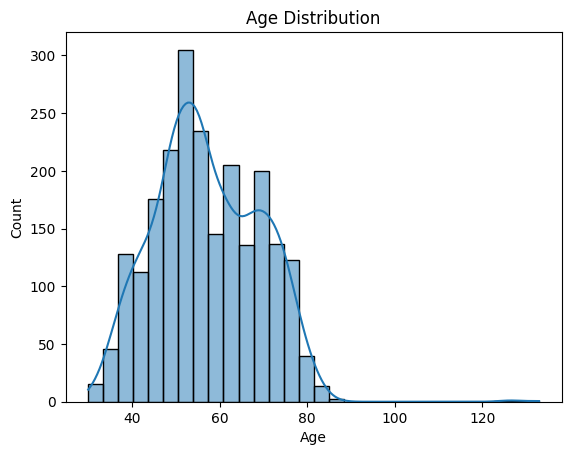

In [184]:
sns.histplot(df["Age"],bins=30,kde=True)
plt.title('Age Distribution')
plt.show()


In [185]:
describeFeat('Age')

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

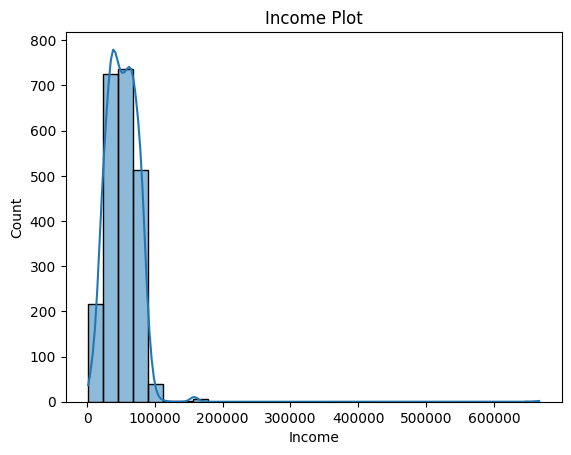

In [186]:
sns.histplot(df["Income"],bins=30,kde=True)
plt.title("Income Plot")
plt.show()

In [187]:
describeFeat('Income') # right skew (+ve)

count      2240.000000
mean      52233.958482
std       25049.149387
min        1730.000000
25%       35538.750000
50%       51381.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64

<Axes: xlabel='totalSpending', ylabel='Count'>

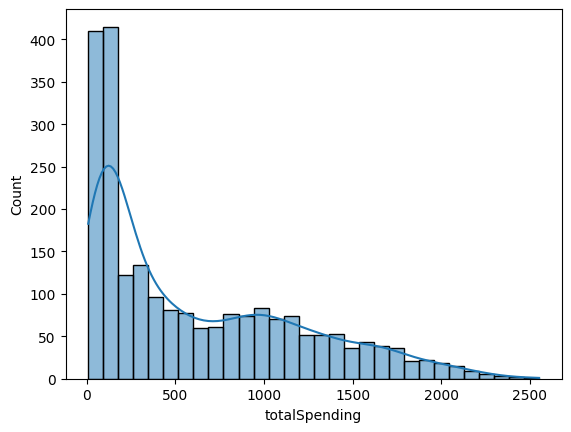

In [188]:
sns.histplot(df["totalSpending"], bins=30, kde=True)

#### Categorical Analysis

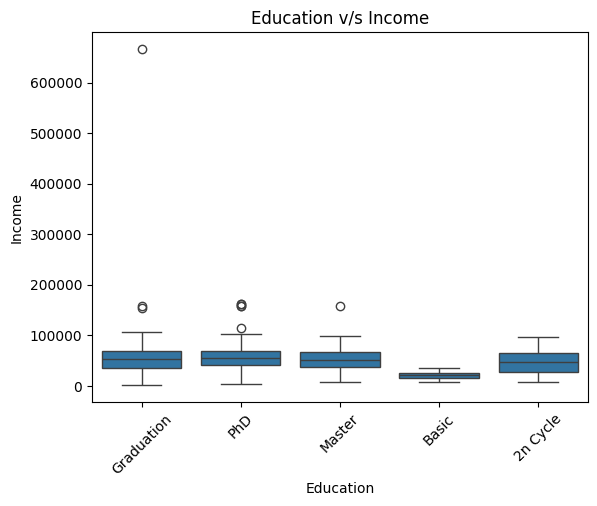

In [189]:
# comparing education and income
sns.boxplot(data=df, x='Education', y='Income')
plt.xticks(rotation=45)
plt.title('Education v/s Income')
plt.show()

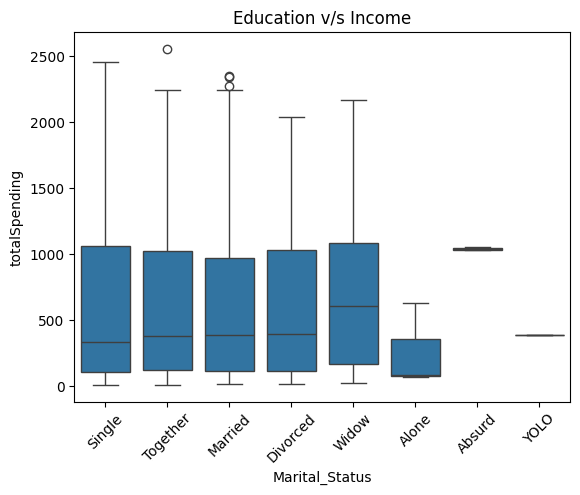

In [190]:
sns.boxplot(x=df["Marital_Status"], y=df['totalSpending'])
plt.xticks(rotation=45)
plt.title('Education v/s Income')
plt.show()

[]

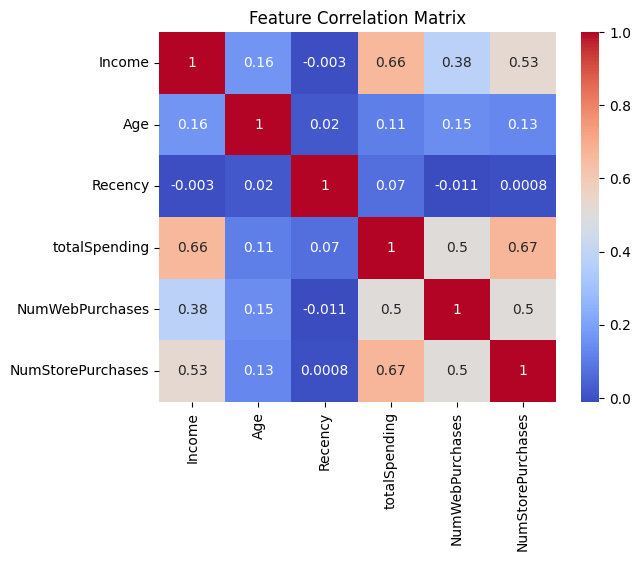

In [191]:
corr = df['Income,Age,Recency,totalSpending,NumWebPurchases,NumStorePurchases'.split(',')].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.plot()

In [192]:
pivot_income = df.pivot_table(values="Income", index="Education", columns="Marital_Status", aggfunc="median")
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49118.0,46094.0,49514.0,45204.0,47682.0,NaN
Basic,NaN,NaN,9548.0,22352.0,16383.0,23179.0,22123.0,NaN
Graduation,79244.0,34176.0,55635.0,50737.0,50184.0,53991.5,58275.0,NaN
Master,65487.0,61331.0,49476.0,53088.5,49494.0,48974.0,55441.5,NaN
PhD,NaN,35860.0,50613.5,56696.0,50288.0,56575.0,57032.0,48432.0


[]

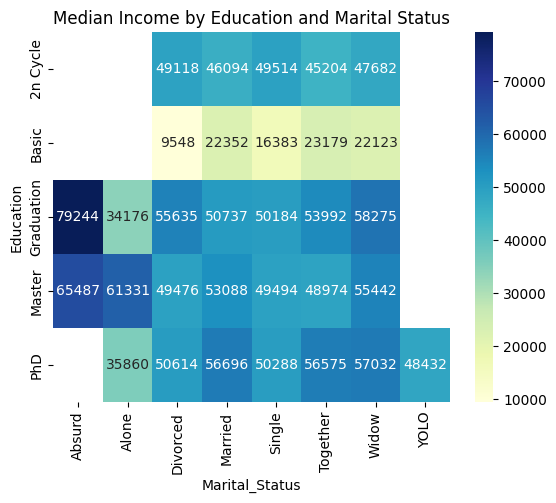

In [193]:
sns.heatmap(pivot_income, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title("Median Income by Education and Marital Status")
plt.plot()

In [194]:
group1 = df.groupby("Education")['totalSpending'].mean().sort_values(ascending=False)
group1

Education
PhD           688.582305
Graduation    619.085182
Master        618.970270
2n Cycle      498.546798
Basic         107.407407
Name: totalSpending, dtype: float64

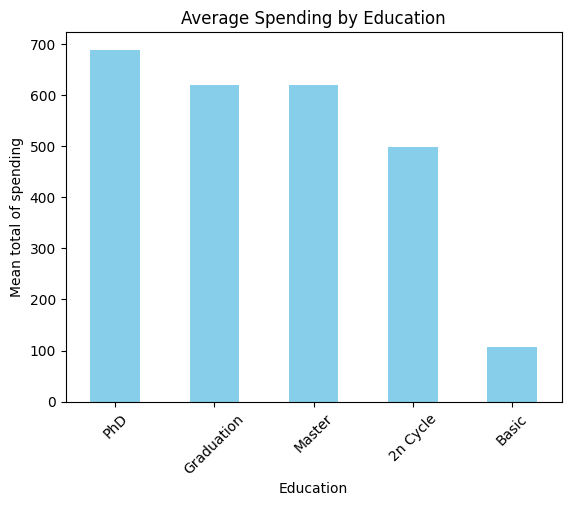

In [195]:
group1.plot(kind='bar', color='skyblue')
plt.title('Average Spending by Education')
plt.ylabel('Mean total of spending')
plt.xticks(rotation=45)
plt.show()

In [196]:
df["acceptedAny"] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)
df["acceptedAny"].unique()
df['acceptedAny']= df['acceptedAny'].apply(lambda x: 1 if x > 0 else 0)
df["acceptedAny"].unique()

array([1, 0], dtype=int64)

In [197]:
group2 = df.groupby("Marital_Status")["acceptedAny"].mean().sort_values(ascending=False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.350649
Alone       0.333333
Single      0.308333
Divorced    0.297414
Married     0.251157
Together    0.250000
Name: acceptedAny, dtype: float64

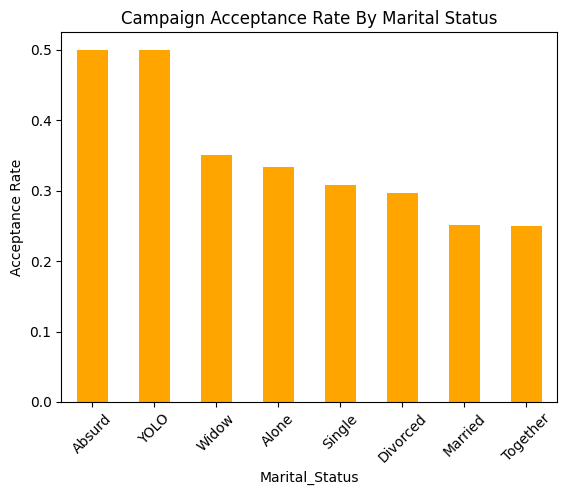

In [198]:
group2.plot(kind='bar', color='orange')
plt.title('campaign acceptance rate by marital status'.title())
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=45)
plt.show()

In [199]:
group3 = df.groupby('ageGroup')["Income"].mean()

C:\Users\SHREE\AppData\Local\Temp\ipykernel_13868\1780349285.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby('ageGroup')["Income"].mean()


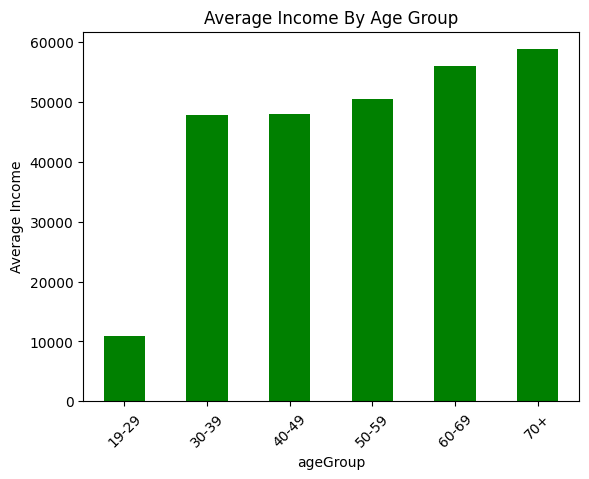

In [200]:
group3.plot(kind='bar', color='green')
plt.title("average income by age group".title())
plt.xticks(rotation=45)
plt.ylabel('Average Income')
plt.show()

In [201]:
df.columns

Index(['ID', 'Age', 'Year_Birth', 'Education', 'Marital_Status',
       'totalChildren', 'Income', 'totalSpending', 'Kidhome', 'customerSince',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'ageGroup', 'acceptedAny'],
      dtype='object')

In [202]:
df.Income.isna().sum()

0

In [203]:
features = "Age,Income,totalSpending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency".split(',')

In [204]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [205]:
X_scaled = scaler.fit_transform(df[features])

In [206]:
from sklearn.cluster import KMeans

In [207]:

wcss = []

In [208]:
for i in range(2,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [209]:
wcss

[10397.25532695348,
 9463.187502913626,
 8314.83747569614,
 7721.930516811322,
 7241.522626860893,
 6852.150718965193,
 6569.771175348208,
 6389.168321919814]

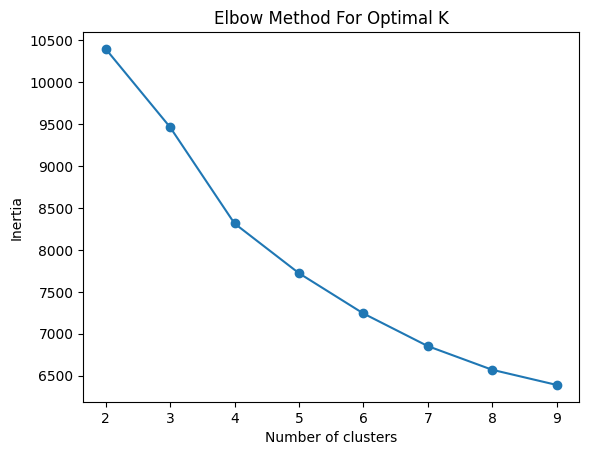

In [211]:
plt.plot(range(2,10), wcss, marker='o')
plt.title("Elbow Method For Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [218]:
kmeans = KMeans(n_clusters=6)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [219]:
df.head()

,ID,Age,Year_Birth,Education,Marital_Status,totalChildren,Income,totalSpending,Kidhome,customerSince,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,ageGroup,acceptedAny,Clusters,Cluster
0,5524,69,1957,Graduation,Single,0,58138.0,1587,0,5021,...,0,0,0,3,11,1,60-69,1,4,4
1,2174,72,1954,Graduation,Single,2,46344.0,59,1,4175,...,0,0,0,3,11,0,70+,0,2,2
2,4141,61,1965,Graduation,Together,0,71613.0,760,0,4522,...,0,0,0,3,11,0,60-69,0,4,5
3,6182,42,1984,Graduation,Together,1,26646.0,74,1,4115,...,0,0,0,3,11,0,40-49,0,3,0
4,5324,45,1981,PhD,Married,1,58293.0,501,1,4371,...,0,0,0,3,11,0,40-49,0,0,3


In [220]:
cluster_summary = df.groupby("Cluster")[features].mean()

In [221]:
cluster_summary

,Age,Income,totalSpending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,50.518764,31892.342163,96.262693,1.958057,3.011038,6.653422,24.905077
1,56.678351,79055.777320,1336.243299,4.303093,8.412371,2.239175,50.870103
2,70.321918,45336.116438,232.965753,2.510274,4.154110,5.075342,59.530822
3,50.109661,33657.677546,187.373368,2.488251,3.292428,7.036554,76.655352
4,61.560372,63091.524768,1032.569659,7.944272,8.718266,5.820433,66.040248
5,59.641447,58247.319079,669.042763,6.328947,7.355263,5.763158,19.664474


In [222]:
df['Cluster'].value_counts()

Cluster
1    485
0    453
3    383
4    323
5    304
2    292
Name: count, dtype: int64

#### Cluster Visualization

In [223]:
from sklearn.decomposition import PCA

In [224]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:,0], pca_data[:,1]

In [225]:
pca_data

array([[ 1.10126885, -0.19594178],
       [-1.32449062,  0.17933788],
       [ 1.8507422 , -1.09804224],
       ...,
       [ 1.26112603,  1.25881601],
       [ 1.82722708, -1.28079347],
       [-0.8451216 , -0.2482181 ]])

In [ ]:
sns.scatterplot(x=df["PCA1"], y=df["PCA2"], hue=df["Cluster"])